Suppose we want to do symmetry expansion on some VQE circuit or other state generated by an arbitrary circuit and we want to add additional stabilizers to detect additional errors. The gates in that circuit are not logical operations of the code defined by the symmetry group, so there is no clear way to compile this circuit into a circuit for the new code. However, suppose there exists a circuit that maps codewords of the original code to the equivalent codewords of the new code. Then we can apply the encoding circuit after the computation to get a codeword of the new code.

We will carry out the following steps with a repetition code:
1. Encode the logical logical $|0\rangle$ state of the original repetition code (stabilized by $ZZI$ and $IZZ$).
2. Carry out a logical gate on the encoded qubit.
3. Apply the circuit that converts codewords of the original repetition code to that of the new code.
4. Measure a logical observable of the new code, mitigating errors using symmetry expansion under the stabilizer group of the new code.

In this case we will prepare the $|\bar{+}\rangle$ state then apply a logical phase gate to get the $Y$-eigenstate $|+i\rangle$.

In [66]:
from typing import List, Tuple
import itertools
import functools
import numpy as np
import matplotlib.pyplot as plt
import cirq
from encoded.repetition_code import (
    generate_stabilizers,
    encoding_repetition
)
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition,
    U_XXX
)
from encoded.symmetry_expansion import symmetry_expansion

In [67]:
def add_noise_register_wise(
    circuit: cirq.Circuit,
    noise_spec: List[Tuple[float, List[cirq.Qid]]]
) -> cirq.Circuit:
    """Add noise of different strengths to different registers.
    
    Arguments:
    circuit: The circuit to apply noise to.
    noise_spec: A list of tuples of the form (noise_rate, qs), where qs is a list of qubits."""

    noisy_ops = []
    for noise_level, qs in noise_spec:
        for q in qs:
            noisy_ops.append(cirq.PhaseFlipChannel(p=noise_level).on(q))
    noisy_moment = cirq.Moment.from_ops(*noisy_ops)

    new_circuit = cirq.Circuit()
    for moment in circuit:
        new_circuit.append(moment)
        new_circuit.append(noisy_moment)
    return new_circuit

In [68]:
all_qs = cirq.LineQubit.range(4)

In [69]:
# Define logical operators of the original repetition code.
logical_x = cirq.X.on(all_qs[0]) * cirq.X.on(all_qs[1]) * cirq.X.on(all_qs[2])
logical_z = cirq.Z.on(all_qs[0])
logical_y = 1.0j * logical_x * logical_z
# Define Y for the new code.
y_bar = 1.0j * x_bar * z_bar

In [70]:
def run_plus_i(p_three_qubit, p_extra_qubit):
    all_qs = cirq.LineQubit.range(4)
    noise_spec = [(p_three_qubit, all_qs[:3]), (p_extra_qubit, [all_qs[-1]])]

    circuit = cirq.Circuit()
    encoding_ckt, qs = encoding_repetition('+', 3)
    noisy_encoding_circuit = add_noise_register_wise(encoding_ckt, noise_spec)
    assert set(qs).issubset(set(all_qs))

    logical_s_circuit = cirq.Circuit()
    logical_s_circuit.append(cirq.S(qs[0]))
    noisy_s_circuit = add_noise_register_wise(logical_s_circuit, noise_spec)

    noisy_U_XXX = add_noise_register_wise(U_XXX, noise_spec)

    circuit += noisy_encoding_circuit
    circuit += noisy_s_circuit
    circuit += noisy_U_XXX

    sim = cirq.DensityMatrixSimulator()
    result = sim.simulate_expectation_values(circuit, y_bar)
    return result[0]

In [71]:
def run_plus_i_no_extension(noise_rate):
    noise_spec = [(noise_rate, all_qs[:3])]

    circuit = cirq.Circuit()
    encoding_ckt, qs = encoding_repetition('+', 3)
    noisy_encoding_circuit = add_noise_register_wise(encoding_ckt, noise_spec)
    assert set(qs).issubset(set(all_qs))

    logical_s_circuit = cirq.Circuit()
    logical_s_circuit.append(cirq.S(qs[0]))
    noisy_s_circuit = add_noise_register_wise(logical_s_circuit, noise_spec)

    circuit += noisy_encoding_circuit
    circuit += noisy_s_circuit

    sim = cirq.DensityMatrixSimulator()
    result = sim.simulate_expectation_values(circuit, logical_y)
    return result[0]

In [79]:
def run_plus_i_physical(noise_rate):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit()
    circuit.append(cirq.H(q))
    circuit.append(cirq.S(q))
    noisy_circuit = add_noise_register_wise(circuit, [(noise_rate, [q])])
    observable = 1. * cirq.Y.on(q)
    sim = cirq.DensityMatrixSimulator()
    result = sim.simulate_expectation_values(noisy_circuit, observable)
    return result[0]

In [82]:
noise_ratio = 1e-2
three_q_noise_rates = np.logspace(-8, -2, num=10)
errors = []
errs_no_extension = []
errs_physical = []
for noise_rate in three_q_noise_rates:
    exp_y = run_plus_i(noise_rate, noise_ratio * noise_rate)
    errors.append(abs(1. - exp_y))
    exp_y_no_extend = run_plus_i_no_extension(noise_rate)
    errs_no_extension.append(abs(1. - exp_y_no_extend))
    exp_y_physical = run_plus_i_physical(noise_rate)
    errs_physical.append(abs(1. - exp_y_physical))

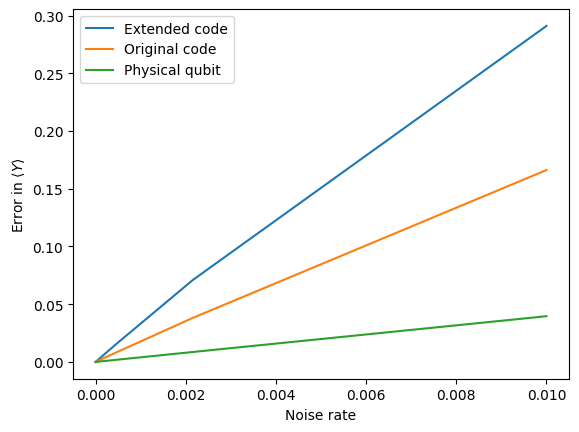

In [84]:
fig, ax = plt.subplots()
ax.plot(three_q_noise_rates, errors, label="Extended code")
ax.plot(three_q_noise_rates, errs_no_extension, label="Original code")
ax.plot(three_q_noise_rates, errs_physical, label="Physical qubit")
ax.set_xlabel("Noise rate")
ax.set_ylabel(r"Error in $\langle Y \rangle$")
ax.legend()